## Physical insight into the optimized PVs

## 1) Setup

In [25]:
%run -i imports.py
%matplotlib inline
data_tag = 'oxyfuel'
target_variables_indices = [0, 2, 3, 5, 6, 9, 10]
pure_streams = True #DO NOT modify it, unless you want to perform a "non-trainable pure streams analysis" (Refer to Section 3.4. The impact of training data preprocessing of https://doi.org/10.1016/j.combustflame.2025.114152)
pure_streams_prefix = 'tps'
data_type = 'FPF'
%run -i ../scripts/fpf-load-data.py

Python==3.10.13

numpy==1.26.2
pandas==2.1.3
scipy==1.11.4
scikit-learn==1.3.2
PCAfold==2.2.0

Using: T, O2, OH, H2, H2O, CO, CO2 as target state variables at the decoder output.

25829 observations
27 state variables


<Figure size 640x480 with 0 Axes>

In [26]:
def populate_weights_matrix(model_weights_filename, random_seeds_list):

    weights_collected = np.zeros((len(random_seeds_list), n_variables-1))

    for i, random_seed in enumerate(random_seeds_list):

        hf = h5py.File(model_weights_filename + str(random_seed) + '.h5', 'r')
        current_weights = np.array(hf.get('0'))
        hf.close()
    
        current_weights = np.abs(current_weights) / np.max(np.abs((current_weights)))
    
        weights_collected[i,:] = current_weights.ravel()

    return weights_collected

In [27]:
def populate_max_matrix(model_weights_filename, random_seeds_list):

    max_collected = np.zeros((len(random_seeds_list), n_variables-1))

    for i, random_seed in enumerate(random_seeds_list):

        hf = h5py.File(model_weights_filename + str(random_seed) + '.h5', 'r')
        current_weights = np.array(hf.get('0'))
        hf.close()

        scaled_state_space = state_space[:,1::] * np.abs(current_weights.ravel())

        current_max = np.max(scaled_state_space, axis=0)

        max_collected[i,:] = current_max.ravel() / np.max(current_max.ravel())

    return max_collected

In [28]:
def plot_violins(weights_collected):
    
    fig, ax = plt.subplots(figsize=(10,3))
    xrange = [i for i in range(0,n_variables-1)]
    violin_parts = plt.violinplot(weights_collected, positions=xrange, widths=0.8);
    plt.scatter(xrange, np.median(weights_collected, axis=0), s=20, c='k')
    plt.xticks(xrange, tex_names, rotation=90, fontsize=18, zorder=10);
    plt.yticks(fontsize=18)
    plt.ylabel('$|w_i|$ [$-$]', fontsize=20)
    plt.grid(alpha=0.3, zorder=1)
    plt.yticks([0,0.5,1])
    for pc in violin_parts['bodies']:
        pc.set_facecolor('red')
        pc.set_edgecolor('red')
    for partname in ('cbars','cmins','cmaxes'):
        vp = violin_parts[partname]
        vp.set_edgecolor('k')
        vp.set_linewidth(1.5)
        

In [29]:
def plot_max_violins(max_collected):
    
    fig, ax = plt.subplots(figsize=(10,3))
    xrange = [i for i in range(0,n_variables-1)]
    violin_parts = plt.violinplot(max_collected, positions=xrange, widths=0.8);
    plt.scatter(xrange, np.median(max_collected, axis=0), s=20, c='k')
    plt.xticks(xrange, tex_names, rotation=90, fontsize=18, zorder=10);
    plt.yticks(fontsize=18)
    plt.ylabel('max$( |w_i| \cdot Y_i)$ [$-$]', fontsize=20)
    plt.grid(alpha=0.3, zorder=1)
    plt.yticks([0,0.5,1])
    for pc in violin_parts['bodies']:
        pc.set_facecolor('red')
        pc.set_edgecolor('red')
    for partname in ('cbars','cmins','cmaxes'):
        vp = violin_parts[partname]
        vp.set_edgecolor('k')
        vp.set_linewidth(1.5)


## 2) Distribution of the scaled mass fraction

In [30]:
### Select the seed(s) you want to analyse
# random_seeds_list = [i for i in range(0,9)]
random_seeds_list = [0]
# random_seeds_list = [i for i in range(0,2)]

In [31]:
tex_names = tex_names[1::]

In [32]:
### Adapt to your own best-model-weights.h5 file
model_weights_filename = '../scripts/f-PV-' + pure_streams_prefix + '-FPF-oxyfuel-target-T-O2-OH-H2-H2O-CO-CO2-RandomNormal-e-300000-CD-300000-lr-0.01-alr-0.001-scale-none-darch-0-10-10-rho-0.9-mom-0.5-momcent-no-best-model-weights-rs-'

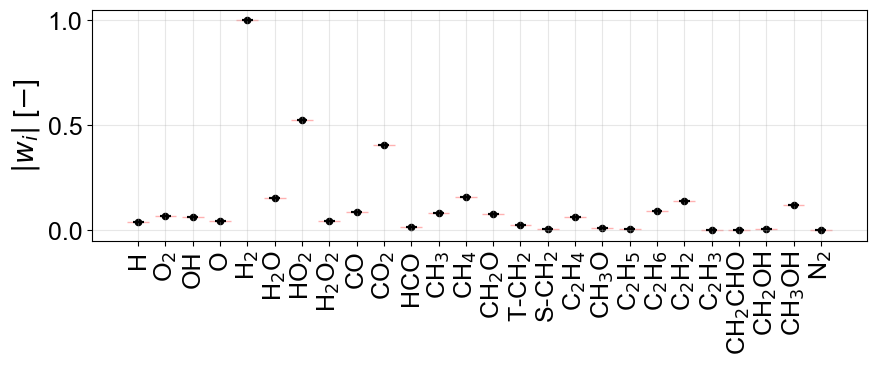

In [33]:
import matplotlib.pyplot as plt
weights_collected = populate_weights_matrix(model_weights_filename, random_seeds_list)
plot_violins(weights_collected)

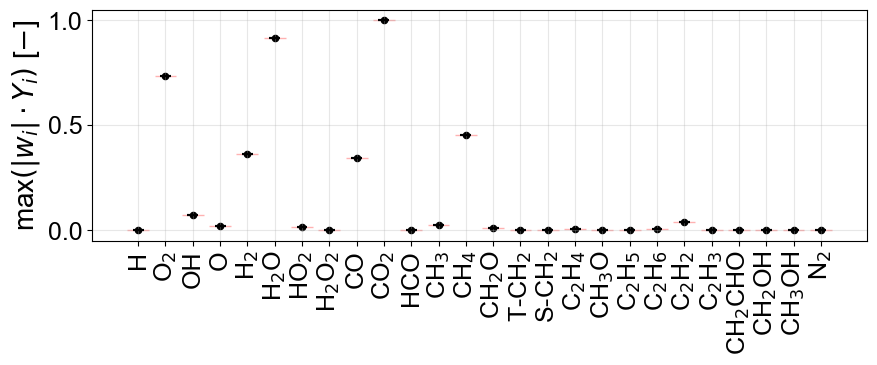

In [34]:
max_collected = populate_max_matrix(model_weights_filename, random_seeds_list)
plot_max_violins(max_collected)